In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

from torch.utils.data import DataLoader
from torchvision.utils import make_grid, save_image

import numpy as np
import matplotlib.pyplot as plt
import os

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

latent_dim = 100
num_classes = 10
embedding_dim = 10

batch_size = 128
epochs = 100
lr = 2e-4

image_size = 28
channels = 1

sample_dir = "samples"
os.makedirs(sample_dir, exist_ok=True)

In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataset = torchvision.datasets.FashionMNIST(
    root="./data",
    train=True,
    transform=transform,
    download=True
)

loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

100%|██████████| 26.4M/26.4M [00:02<00:00, 11.1MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 179kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.27MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 27.7MB/s]


In [4]:
class Generator(nn.Module):

    def __init__(self):
        super().__init__()

        self.label_emb = nn.Embedding(num_classes, embedding_dim)

        self.model = nn.Sequential(

            nn.ConvTranspose2d(latent_dim + embedding_dim, 256, 7, 1, 0),
            nn.BatchNorm2d(256),
            nn.ReLU(True),

            nn.ConvTranspose2d(256, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.ConvTranspose2d(64, 1, 3, 1, 1),
            nn.Tanh()
        )

    def forward(self, z, labels):

        embedding = self.label_emb(labels)

        x = torch.cat([z, embedding], dim=1)

        x = x.unsqueeze(2).unsqueeze(3)

        return self.model(x)

In [5]:
from torch.nn.utils import spectral_norm

class Discriminator(nn.Module):

    def __init__(self):
        super().__init__()

        self.label_emb = nn.Embedding(num_classes, image_size * image_size)

        self.model = nn.Sequential(

            spectral_norm(nn.Conv2d(2, 64, 4, 2, 1)),
            nn.LeakyReLU(0.2),

            spectral_norm(nn.Conv2d(64, 128, 4, 2, 1)),
            nn.LeakyReLU(0.2),

            spectral_norm(nn.Conv2d(128, 256, 3, 2, 1)),
            nn.LeakyReLU(0.2),

            spectral_norm(nn.Conv2d(256, 1, 3, 1, 0)),

            nn.AdaptiveAvgPool2d(1)   # ⭐ FIX
        )

    def forward(self, img, labels):

        embedding = self.label_emb(labels)
        embedding = embedding.view(-1, 1, image_size, image_size)

        x = torch.cat([img, embedding], dim=1)

        x = self.model(x)

        return x.view(-1)

In [6]:
G = Generator().to(device)
D = Discriminator().to(device)

In [7]:
criterion = nn.BCEWithLogitsLoss()

In [8]:
optimizer_G = optim.Adam(G.parameters(), lr=lr, betas=(0.5, 0.999))
optimizer_D = optim.Adam(D.parameters(), lr=lr, betas=(0.5, 0.999))

In [9]:
def real_labels(size):
    return torch.empty(size).uniform_(0.9, 1.0).to(device)

def fake_labels(size):
    return torch.zeros(size).to(device)

In [10]:
fixed_noise = torch.randn(100, latent_dim).to(device)

fixed_labels = torch.arange(0,10).repeat(10).to(device)

In [11]:
g_losses = []
d_losses = []

for epoch in range(epochs):

    for imgs, labels in loader:

        batch_size = imgs.size(0)

        imgs = imgs.to(device)
        labels = labels.to(device)


        # ==========================
        # Train Discriminator
        # ==========================

        optimizer_D.zero_grad()

        real = torch.empty(batch_size).uniform_(0.9, 1.0).to(device)
        fake = torch.zeros(batch_size).to(device)

        real_output = D(imgs, labels)

        loss_real = criterion(real_output, real)


        noise = torch.randn(batch_size, latent_dim).to(device)

        fake_imgs = G(noise, labels)

        fake_output = D(fake_imgs.detach(), labels)

        loss_fake = criterion(fake_output, fake)

        loss_D = loss_real + loss_fake

        loss_D.backward()

        optimizer_D.step()


        # ==========================
        # Train Generator
        # ==========================

        optimizer_G.zero_grad()

        output = D(fake_imgs, labels)

        loss_G = criterion(output, real)

        loss_G.backward()

        optimizer_G.step()


    # store losses

    g_losses.append(loss_G.item())
    d_losses.append(loss_D.item())


    print(f"Epoch [{epoch+1}/{epochs}]  D_loss: {loss_D.item():.4f}  G_loss: {loss_G.item():.4f}")


    # ==========================
    # Save image grid every 5 epochs
    # ==========================

    if (epoch + 1) % 5 == 0:

        with torch.no_grad():

            fake = G(fixed_noise, fixed_labels)

            grid = make_grid(fake, nrow=10, normalize=True)

            save_image(grid, f"{sample_dir}/epoch_{epoch+1}.png")

Epoch [1/100]  D_loss: 0.4246  G_loss: 2.6135
Epoch [2/100]  D_loss: 1.2752  G_loss: 0.8854
Epoch [3/100]  D_loss: 1.3342  G_loss: 0.8505
Epoch [4/100]  D_loss: 1.3177  G_loss: 0.8417
Epoch [5/100]  D_loss: 1.2788  G_loss: 0.8123
Epoch [6/100]  D_loss: 1.3316  G_loss: 0.8030
Epoch [7/100]  D_loss: 1.3008  G_loss: 0.8166
Epoch [8/100]  D_loss: 1.3511  G_loss: 0.7754
Epoch [9/100]  D_loss: 1.3645  G_loss: 0.7621
Epoch [10/100]  D_loss: 1.3826  G_loss: 0.7587
Epoch [11/100]  D_loss: 1.3516  G_loss: 0.7671
Epoch [12/100]  D_loss: 1.3694  G_loss: 0.7445
Epoch [13/100]  D_loss: 1.3732  G_loss: 0.7745
Epoch [14/100]  D_loss: 1.3587  G_loss: 0.7553
Epoch [15/100]  D_loss: 1.3879  G_loss: 0.7550
Epoch [16/100]  D_loss: 1.3864  G_loss: 0.7481
Epoch [17/100]  D_loss: 1.3729  G_loss: 0.7570
Epoch [18/100]  D_loss: 1.3691  G_loss: 0.7704
Epoch [19/100]  D_loss: 1.3705  G_loss: 0.7385
Epoch [20/100]  D_loss: 1.3730  G_loss: 0.7853
Epoch [21/100]  D_loss: 1.3795  G_loss: 0.7497
Epoch [22/100]  D_loss

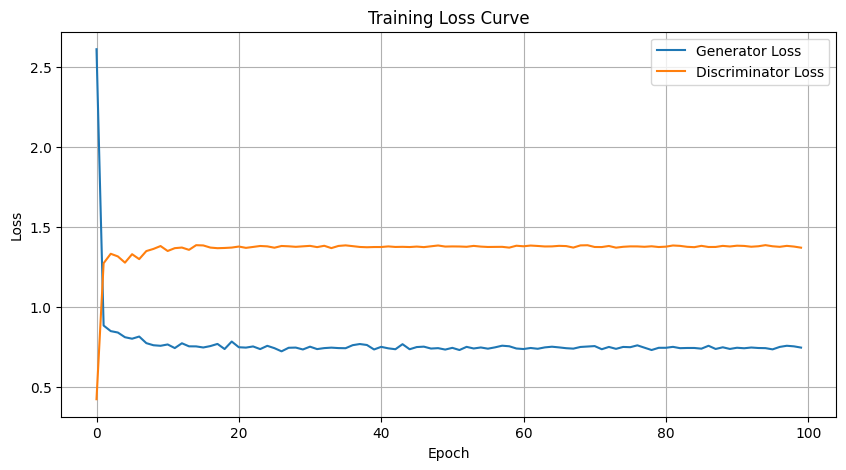

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(g_losses,label="Generator Loss")
plt.plot(d_losses,label="Discriminator Loss")
plt.legend()
plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

In [13]:
plt.savefig("loss_curve.png")

<Figure size 640x480 with 0 Axes>

In [14]:
import shutil

shutil.copy("samples/epoch_5.png","epoch_1.png")
shutil.copy("samples/epoch_50.png","epoch_50.png")
shutil.copy("samples/epoch_100.png","epoch_100.png")

'epoch_100.png'

In [15]:
import os

os.makedirs("fid_fake", exist_ok=True)

In [16]:
G.eval()

count = 0

with torch.no_grad():

    while count < 10000:

        noise = torch.randn(100, latent_dim).to(device)

        labels = torch.randint(0,10,(100,)).to(device)

        fake = G(noise, labels)

        for img in fake:

            save_image(img, f"fid_fake/{count}.png", normalize=True)
            count += 1

            if count >= 10000:
                break

In [17]:
os.makedirs("fid_real", exist_ok=True)

In [18]:
count = 0

for imgs, _ in loader:

    for img in imgs:

        save_image(img, f"fid_real/{count}.png", normalize=True)

        count += 1

        if count >= 10000:
            break

    if count >= 10000:
        break

In [19]:
!pip install pytorch-fid

In [20]:
!python -m pytorch_fid fid_real fid_fake

Downloading: "https://github.com/mseitzer/pytorch-fid/releases/download/fid_weights/pt_inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/pt_inception-2015-12-05-6726825d.pth
100% 91.2M/91.2M [00:00<00:00, 452MB/s]
100% 200/200 [00:42<00:00,  4.74it/s]
100% 200/200 [00:41<00:00,  4.82it/s]
FID:  12.28173027297197


In [23]:
def interpolate(z1, z2, steps=10):

    ratios = torch.linspace(0,1,steps).to(device)

    vectors = [(1-r)*z1 + r*z2 for r in ratios]

    return torch.cat(vectors, dim=0)

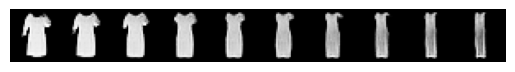

In [24]:
z1 = torch.randn(1, latent_dim).to(device)
z2 = torch.randn(1, latent_dim).to(device)

interp = interpolate(z1, z2, 10)

label = torch.tensor([3]*10).to(device)

with torch.no_grad():

    imgs = G(interp, label)

grid = make_grid(imgs, nrow=10, normalize=True)

plt.imshow(grid.permute(1,2,0).cpu())
plt.axis("off")

save_image(grid, "latent_interpolation.png")

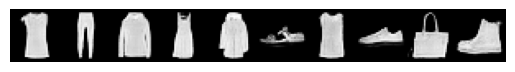

In [25]:
z = torch.randn(1, latent_dim).repeat(10,1).to(device)

labels = torch.arange(0,10).to(device)

with torch.no_grad():

    imgs = G(z, labels)

grid = make_grid(imgs, nrow=10, normalize=True)

plt.imshow(grid.permute(1,2,0).cpu())
plt.axis("off")

save_image(grid, "class_morphing.png")

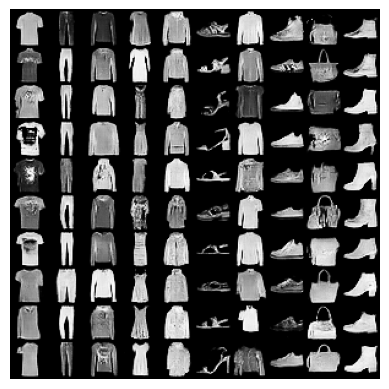

In [26]:
noise = torch.randn(100, latent_dim).to(device)

labels = torch.arange(0,10).repeat(10).to(device)

with torch.no_grad():

    fake = G(noise, labels)

grid = make_grid(fake, nrow=10, normalize=True)

plt.imshow(grid.permute(1,2,0).cpu())
plt.axis("off")

save_image(grid, "final_class_grid.png")

In [27]:
plt.savefig("loss_curve.png")

<Figure size 640x480 with 0 Axes>

In [28]:
from google.colab import files
files.download("final_class_grid.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [29]:
files.download("loss_curve.png")
files.download("latent_interpolation.png")
files.download("class_morphing.png")
files.download("epoch_1.png")
files.download("epoch_50.png")
files.download("epoch_100.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>